# 01 — Análise Exploratória de Dados (EDA)

**Tech Challenge Fase 1 — FIAP PosTech IA para Devs**

Nesse primeiro notebook a ideia é simplesmente *olhar pros dados* antes de sair treinando modelo. A gente carrega o dataset, vê o formato, checa se tem valor faltando, olha como as classes estão distribuídas e tenta entender quais features parecem importantes pra separar tumor maligno de benigno.

**Dataset usado:** Breast Cancer Wisconsin (Diagnostic), que veio direto do `sklearn`. Cada linha é um exame com **30 medidas numéricas** tiradas de imagens de uma massa mamária (raio, textura, perímetro, área etc.) e a coluna alvo diz se o tumor é **maligno (1)** ou **benigno (0)**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data, get_data_info, get_feature_names
from src.preprocessing import get_correlation_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Carregamento dos dados

In [2]:
df = load_data(save_csv=True)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 2. Informações gerais — shape, tipos, nulos

In [3]:
print('Shape:', df.shape)
print('\nTipos:')
print(df.dtypes.value_counts())
print('\nValores nulos por coluna:', df.isna().sum().sum())
info = get_data_info()
info

Shape: (569, 31)

Tipos:
float64    30
int64       1
Name: count, dtype: int64

Valores nulos por coluna: 0


{'shape': (569, 31),
 'class_counts': {0: 357, 1: 212},
 'class_percent': {0: 62.74, 1: 37.26},
 'features': ['mean radius',
  'mean texture',
  'mean perimeter',
  'mean area',
  'mean smoothness',
  'mean compactness',
  'mean concavity',
  'mean concave points',
  'mean symmetry',
  'mean fractal dimension',
  'radius error',
  'texture error',
  'perimeter error',
  'area error',
  'smoothness error',
  'compactness error',
  'concavity error',
  'concave points error',
  'symmetry error',
  'fractal dimension error',
  'worst radius',
  'worst texture',
  'worst perimeter',
  'worst area',
  'worst smoothness',
  'worst compactness',
  'worst concavity',
  'worst concave points',
  'worst symmetry',
  'worst fractal dimension'],
 'nulls_per_column': {'mean radius': 0,
  'mean texture': 0,
  'mean perimeter': 0,
  'mean area': 0,
  'mean smoothness': 0,
  'mean compactness': 0,
  'mean concavity': 0,
  'mean concave points': 0,
  'mean symmetry': 0,
  'mean fractal dimension': 0,
 

## 3. Distribuição das classes

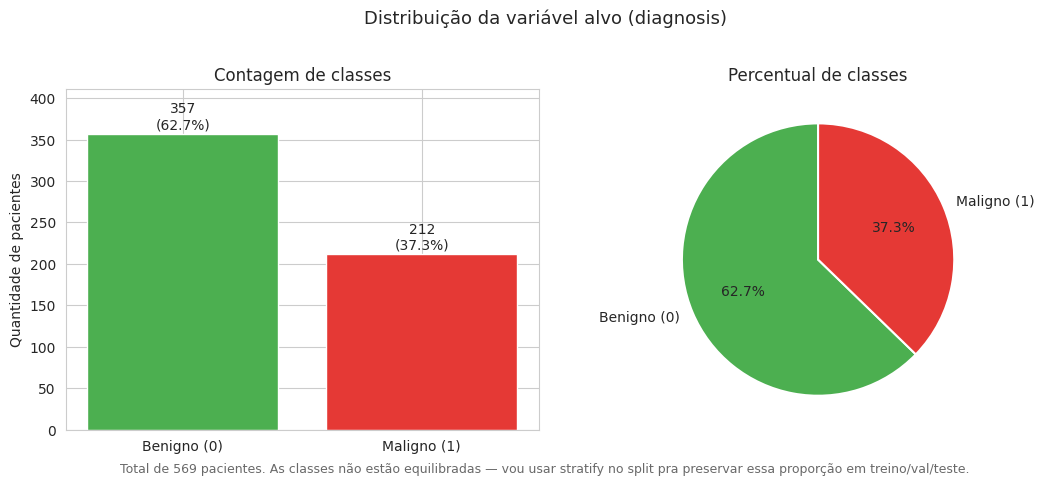

In [4]:
counts = df['diagnosis'].value_counts().sort_index()
total = counts.sum()
labels = ['Benigno (0)', 'Maligno (1)']
colors = ['#4caf50', '#e53935']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

bars = axes[0].bar(labels, counts.values, color=colors)
axes[0].set_title('Contagem de classes')
axes[0].set_ylabel('Quantidade de pacientes')
axes[0].set_ylim(0, counts.max() * 1.15)
for i, v in enumerate(counts.values):
    pct = v / total * 100
    axes[0].text(i, v + total * 0.01, f'{v}\n({pct:.1f}%)', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Percentual de classes')

fig.suptitle('Distribuição da variável alvo (diagnosis)', fontsize=13, y=1.02)
fig.text(0.5, -0.01,
         f'Total de {total} pacientes. As classes não estão equilibradas — vou usar stratify '
         'no split pra preservar essa proporção em treino/val/teste.',
         ha='center', fontsize=9, color='dimgray')
plt.tight_layout()
plt.show()

## 4. Estatísticas descritivas

In [5]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


## 5. Distribuição das features (histogramas)

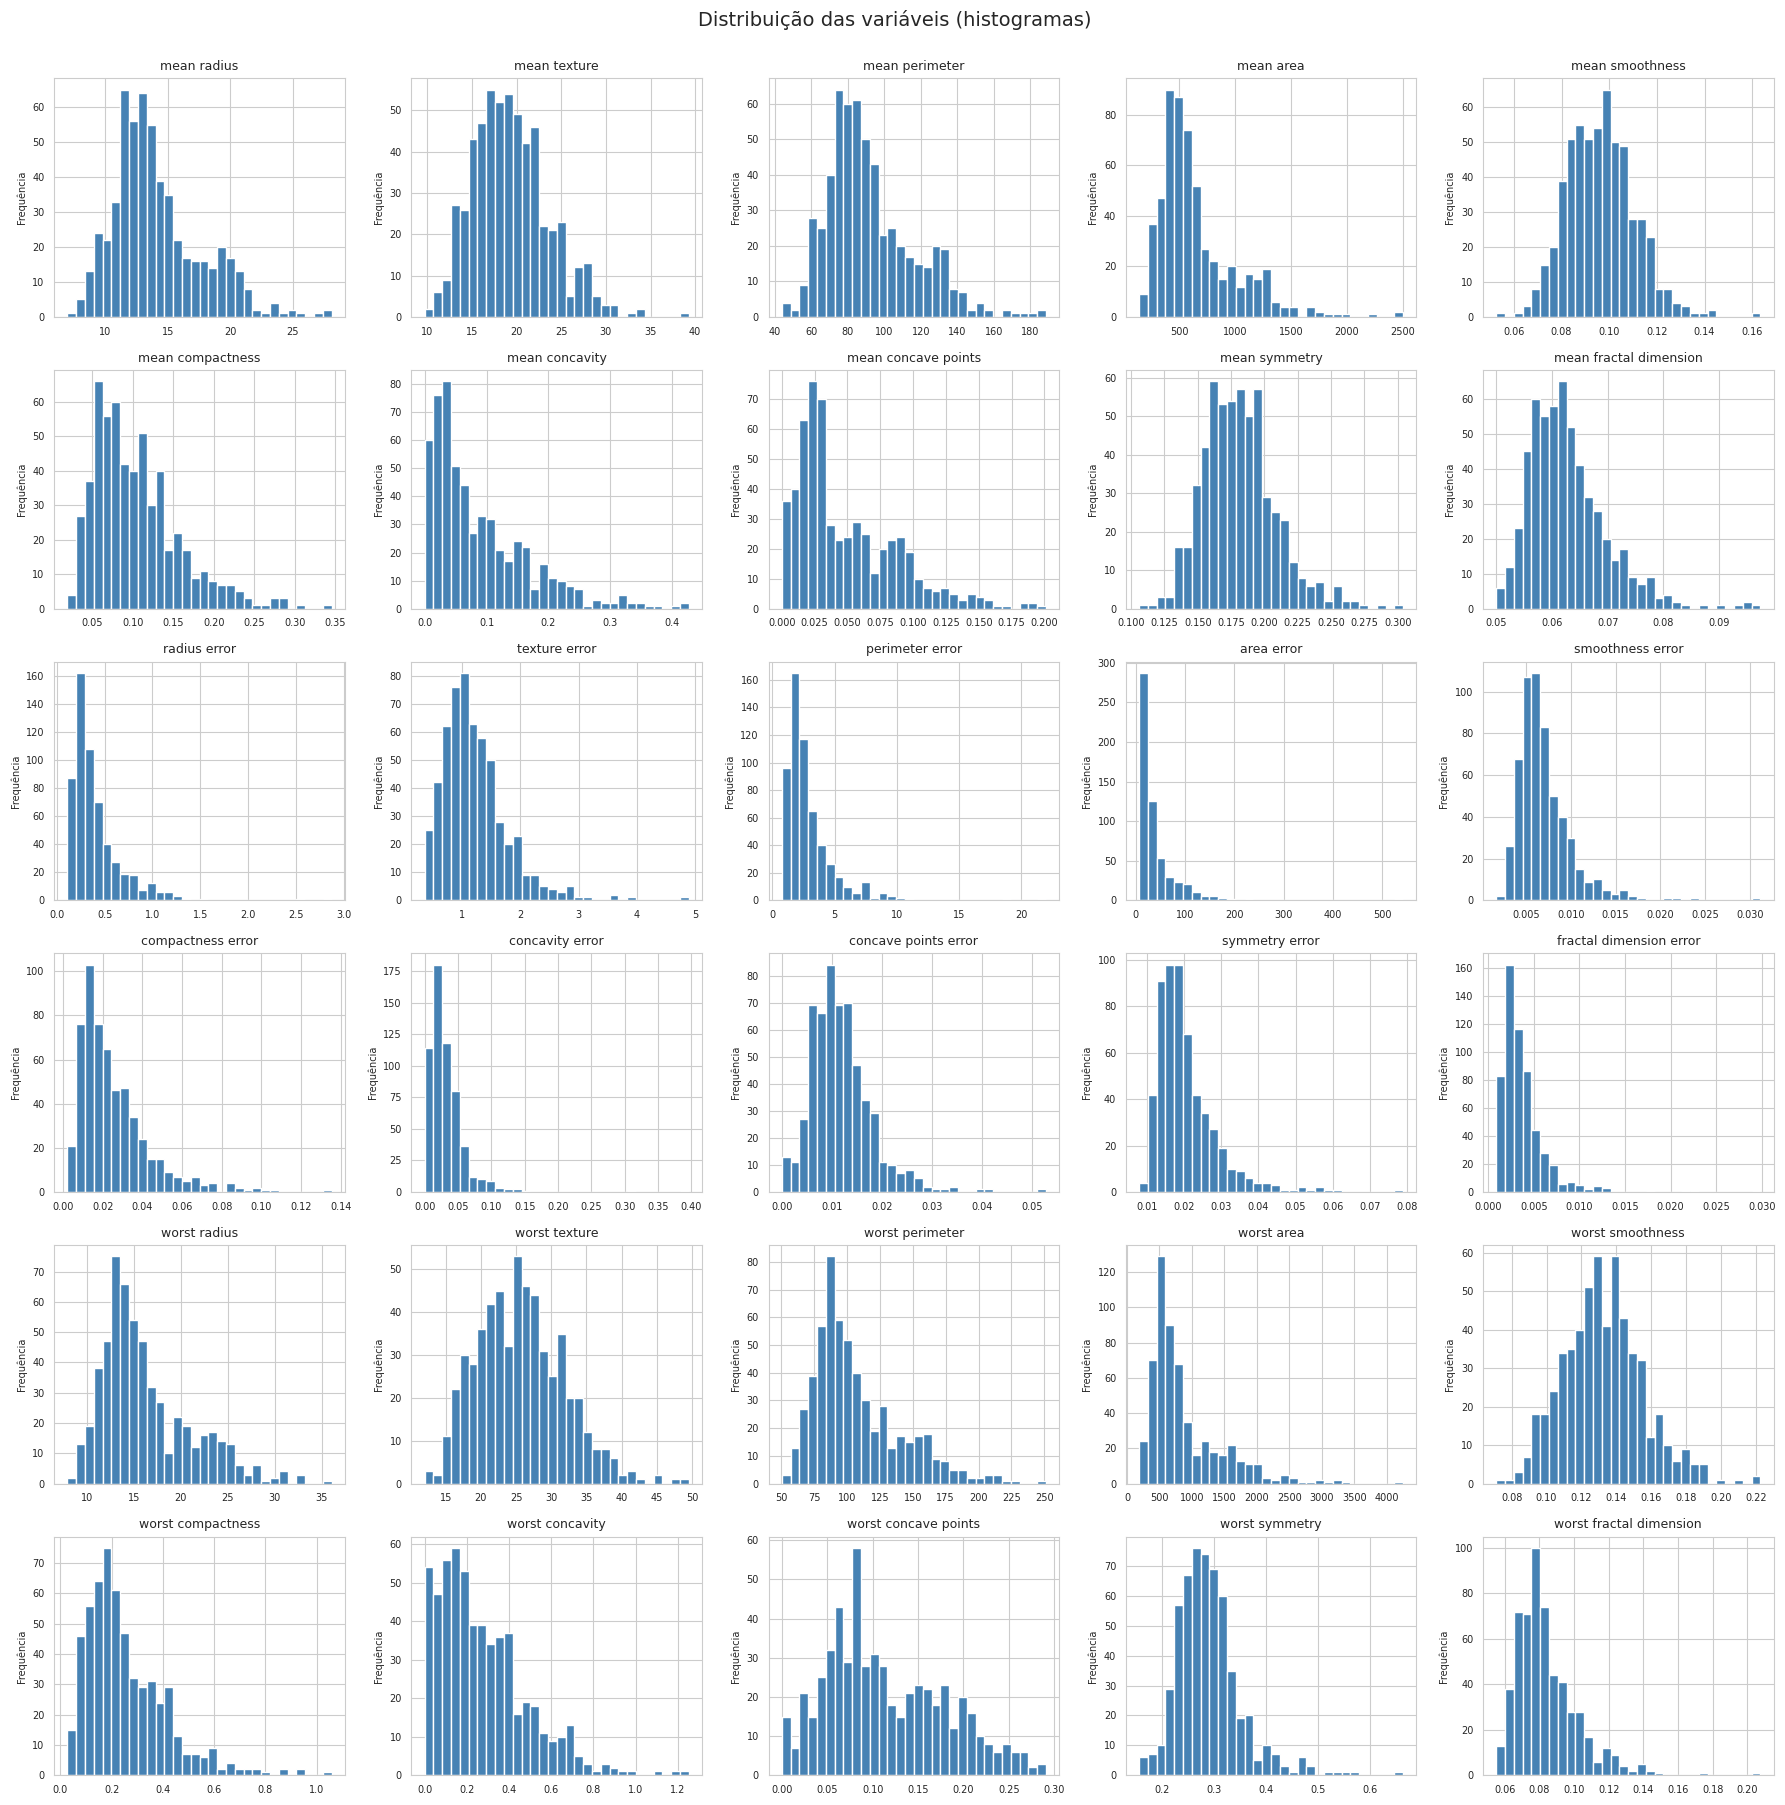

In [6]:
features = get_feature_names()
fig, axes = plt.subplots(6, 5, figsize=(18, 18))
for ax, col in zip(axes.flat, features):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Frequência', fontsize=7)
    ax.tick_params(axis='both', labelsize=7)
fig.suptitle('Distribuição das variáveis (histogramas)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

## 6. Boxplots por classe — comparando benigno vs maligno

/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

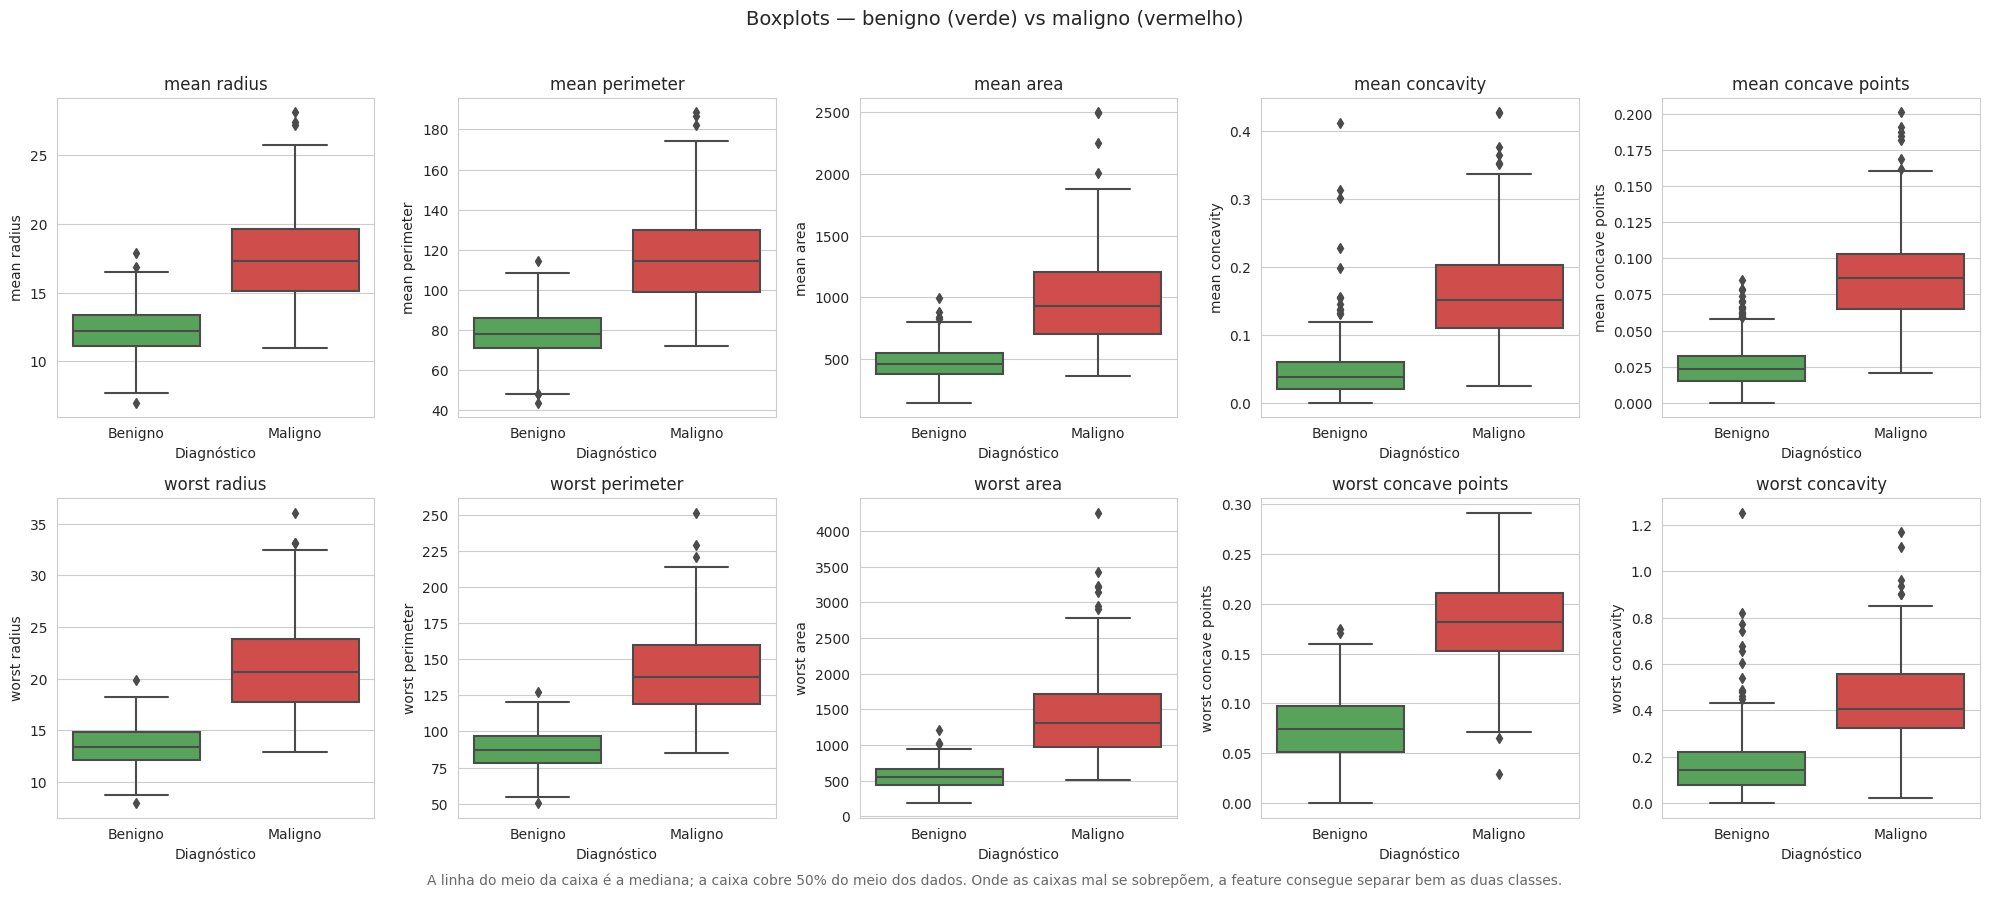

In [7]:
top_features = ['mean radius', 'mean perimeter', 'mean area', 'mean concavity',
                'mean concave points', 'worst radius', 'worst perimeter',
                'worst area', 'worst concave points', 'worst concavity']
fig, axes = plt.subplots(2, 5, figsize=(20, 8.5))
for ax, col in zip(axes.flat, top_features):
    sns.boxplot(data=df, x='diagnosis', y=col, ax=ax, palette=['#4caf50', '#e53935'])
    ax.set_title(col)
    ax.set_xlabel('Diagnóstico')
    ax.set_xticklabels(['Benigno', 'Maligno'])
fig.suptitle('Boxplots — benigno (verde) vs maligno (vermelho)', fontsize=14, y=1.02)
fig.text(0.5, -0.01,
         'A linha do meio da caixa é a mediana; a caixa cobre 50% do meio dos dados. '
         'Onde as caixas mal se sobrepõem, a feature consegue separar bem as duas classes.',
         ha='center', fontsize=10, color='dimgray')
plt.tight_layout()
plt.show()

## 7. Heatmap de correlação

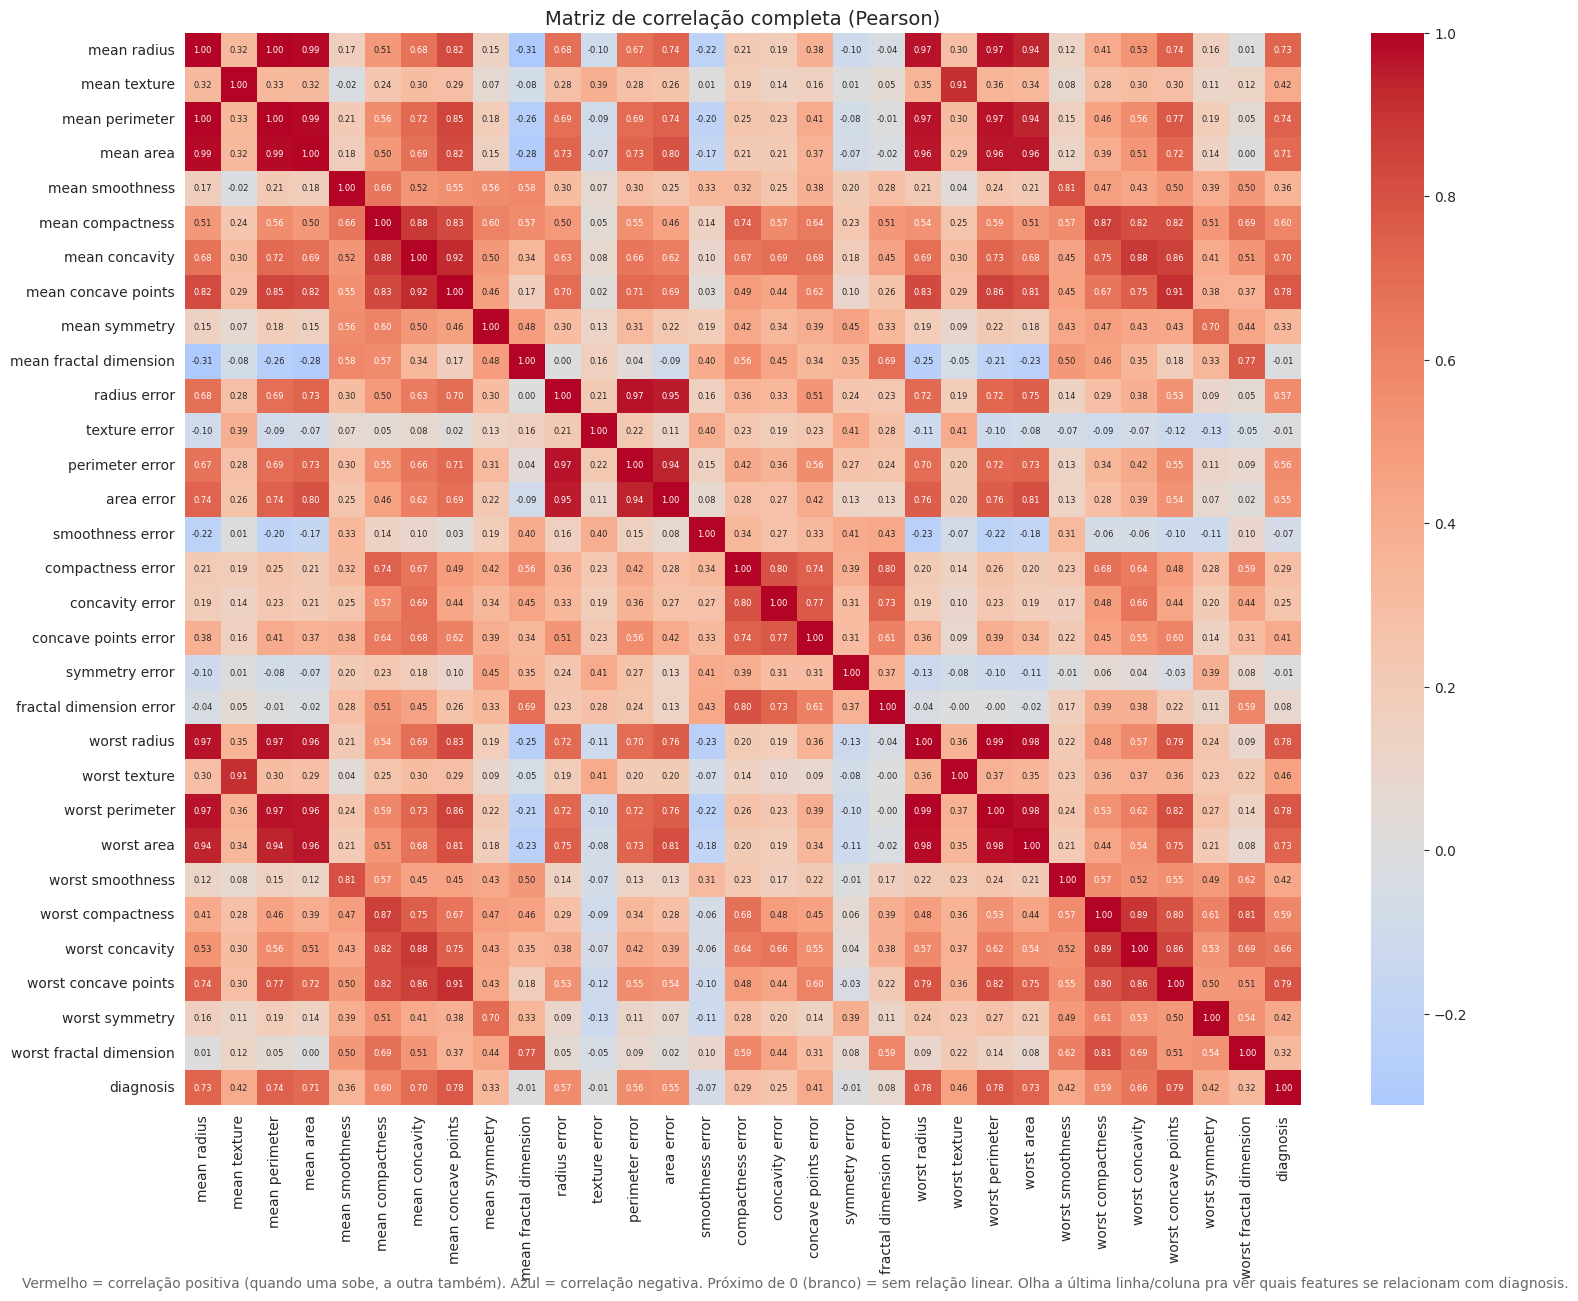

In [8]:
corr = get_correlation_matrix(df)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar=True,
            annot_kws={'size': 6}, ax=ax)
ax.set_title('Matriz de correlação completa (Pearson)', fontsize=14)
fig.text(0.5, 0.005,
         'Vermelho = correlação positiva (quando uma sobe, a outra também). '
         'Azul = correlação negativa. Próximo de 0 (branco) = sem relação linear. '
         'Olha a última linha/coluna pra ver quais features se relacionam com diagnosis.',
         ha='center', fontsize=10, color='dimgray')
plt.tight_layout()
plt.show()

## 8. Top features correlacionadas com o diagnóstico

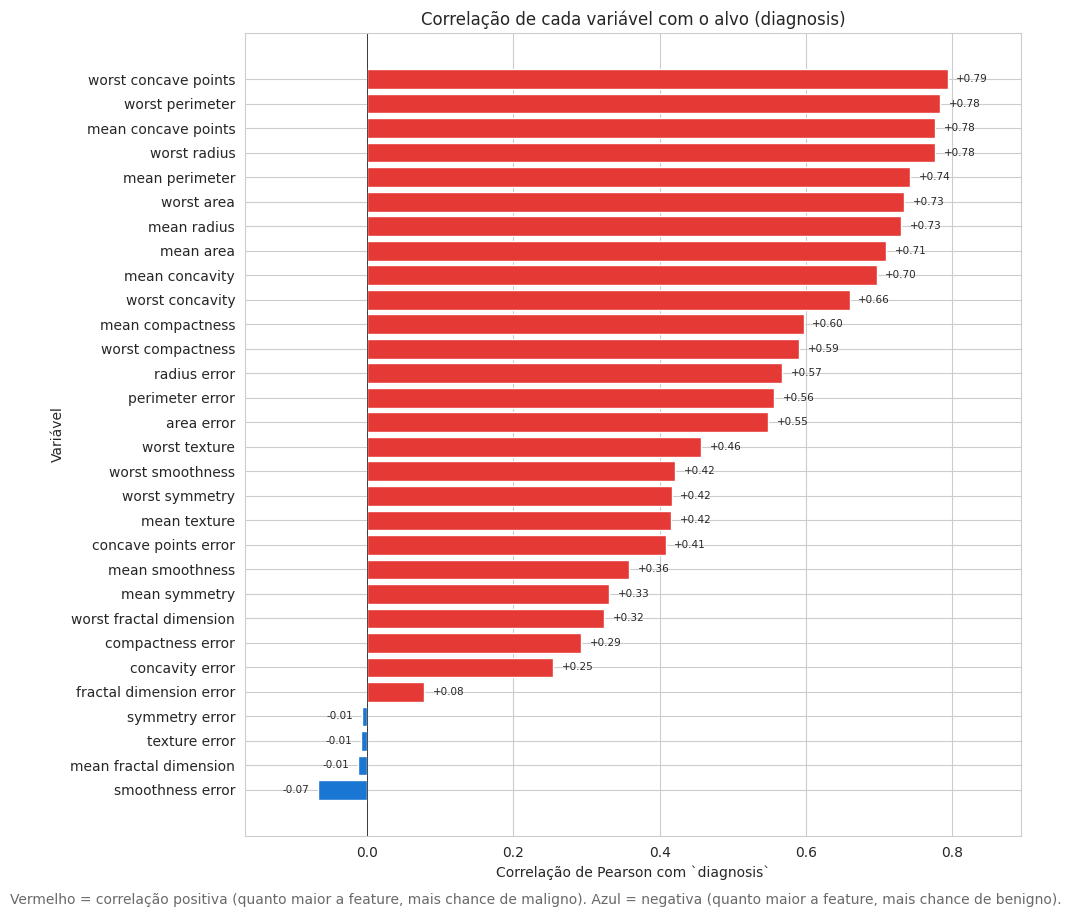

In [9]:
target_corr = corr['diagnosis'].drop('diagnosis').sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#e53935' if v > 0 else '#1976d2' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors)
ax.set_xlabel('Correlação de Pearson com `diagnosis`')
ax.set_ylabel('Variável')
ax.set_title('Correlação de cada variável com o alvo (diagnosis)')
ax.axvline(0, color='black', linewidth=0.5)

# anoto o valor na ponta da barra — fica do lado oposto pra não invadir o gráfico
for bar, v in zip(bars, target_corr.values):
    x = v + (0.012 if v >= 0 else -0.012)
    ha = 'left' if v >= 0 else 'right'
    ax.text(x, bar.get_y() + bar.get_height()/2, f'{v:+.2f}',
            va='center', ha=ha, fontsize=7.5)

ax.set_xlim(target_corr.min() - 0.1, target_corr.max() + 0.1)
fig.text(0.5, -0.01,
         'Vermelho = correlação positiva (quanto maior a feature, mais chance de maligno). '
         'Azul = negativa (quanto maior a feature, mais chance de benigno).',
         ha='center', fontsize=10, color='dimgray')
plt.tight_layout()
plt.show()

## 9. Outliers — violinplots das top 10 features

/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

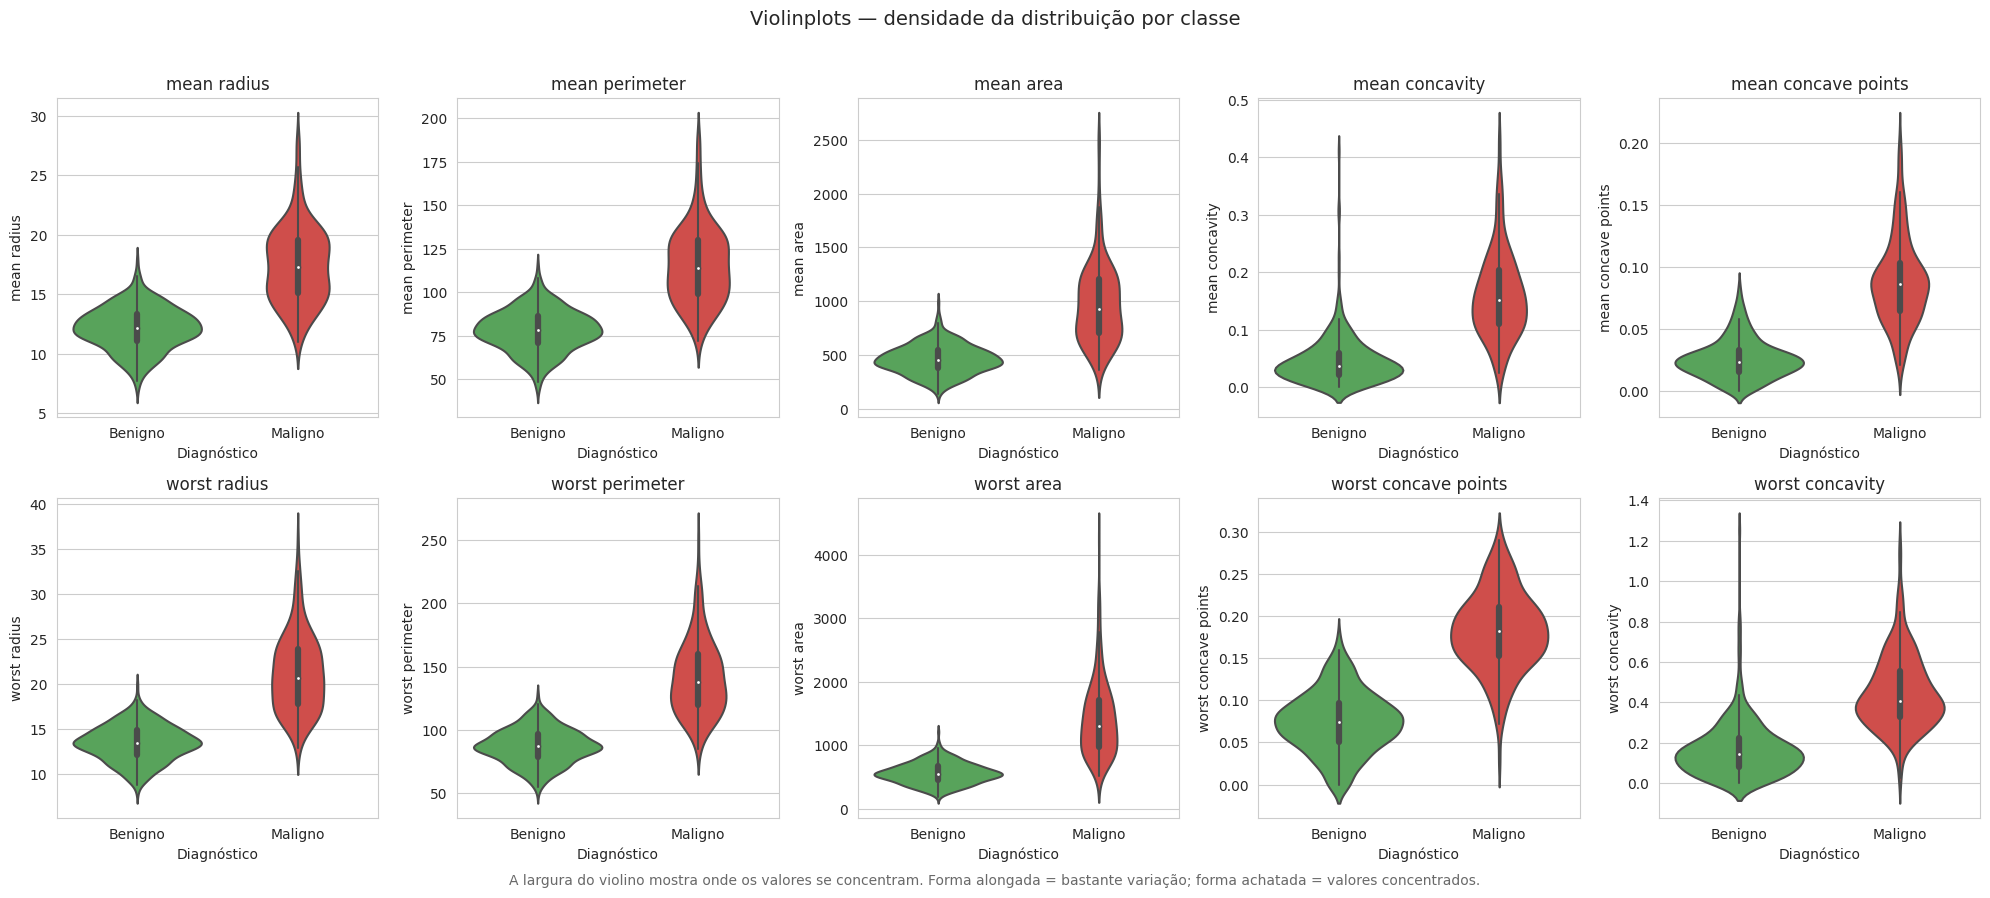

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8.5))
for ax, col in zip(axes.flat, top_features):
    sns.violinplot(data=df, x='diagnosis', y=col, ax=ax, palette=['#4caf50', '#e53935'])
    ax.set_title(col)
    ax.set_xlabel('Diagnóstico')
    ax.set_xticklabels(['Benigno', 'Maligno'])
fig.suptitle('Violinplots — densidade da distribuição por classe', fontsize=14, y=1.02)
fig.text(0.5, -0.01,
         'A largura do violino mostra onde os valores se concentram. '
         'Forma alongada = bastante variação; forma achatada = valores concentrados.',
         ha='center', fontsize=10, color='dimgray')
plt.tight_layout()
plt.show()

## 10. O que eu tirei dessa análise

Depois de explorar os dados, algumas coisas ficaram bem claras:

- **As classes estão um pouco desbalanceadas** (cerca de 63% benigno e 37% maligno), mas nada que precise de técnica especial. Só vou me lembrar de usar `stratify` no `train_test_split` pra manter a proporção nos conjuntos.

- **Não tem valor faltando**, o que é ótimo — uma preocupação a menos. Mesmo assim, vou deixar um `SimpleImputer` no pipeline por precaução (caso o dataset receba dados novos no futuro).

- **As features de tamanho e formato do tumor** (`radius`, `perimeter`, `area`, `concavity` e principalmente as versões `worst`) são as que mais se correlacionam com o diagnóstico. Olhando os boxplots dá pra ver visualmente que tumores malignos tendem a ser maiores e mais irregulares.

- **Existem várias features muito parecidas entre si** (`mean radius`, `radius error` e `worst radius`, por exemplo, todas medem coisa parecida). Isso é multicolinearidade, e pode confundir um modelo como Regressão Logística. Modelos baseados em árvore lidam melhor com isso.

- **As escalas das features são bem diferentes** — `area` chega na casa dos milhares e `smoothness` fica em 0.1. Isso significa que vou **precisar padronizar** antes de usar KNN, SVM ou Regressão Logística, senão a feature com número maior acaba dominando.

- **Tem outliers, especialmente na classe maligna**. Achei melhor não remover, porque eles parecem ser parte do sinal — tumores malignos realmente variam mais do que benignos. Tirar esses pontos podia fazer o modelo perder informação importante.

No próximo notebook (`02_preprocessing`) vou montar o pipeline que resolve esses pontos.